In [2]:
import matplotlib.pyplot as plt # For plotting
import numpy as np              # Linear algebra library
import pandas as pd             # For manipulating tabular data

Step 1: Create the master dataframe

In [4]:
# Load the raw master dataset
df_master = pd.read_csv('cleaned_dataset.csv')

# Drop any rows missing labels and reset the index to establish absolute row positions
df_master = df_master.dropna(subset=['Label']).reset_index(drop=True)

df_master.describe()

,id,Q1,Q2,Q3,Q4,Q8
count,1462.000000,1462.000000,1461.000000,1461.000000,1462.000000,1461.000000
mean,460237.614911,4.321477,3.521561,3.707734,3.391929,4.796030
std,112789.365108,0.884464,1.192031,1.142037,1.297189,22.142305
min,5978.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,407927.000000,4.000000,3.000000,3.000000,2.000000,2.000000
50%,503416.000000,5.000000,4.000000,4.000000,3.000000,3.000000
75%,522169.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,727099.000000,5.000000,5.000000,5.000000,5.000000,800.000000


Step 2: Data split (same code to be used for all sub-models before individual data handling for each question)

In [5]:
# Capture a master index array representing every single row position, and randomize rows
df_master = df_master.sample(frac=1, random_state=42).reset_index(drop=True)

master_indices = np.arange(len(df_master))
labels = df_master['Label']

# Print the first 20 rows of the shuffled dataset to verify randomization
print("=== SHUFFLE VERIFICATION REPORT ===")
print(df_master[['Label']].head(20))

print("\n=== CLASS DISTRIBUTION IN TOP 20 ROWS ===")
print(df_master['Label'].head(20).value_counts())

=== SHUFFLE VERIFICATION REPORT ===
             Label
0    New York City
1            Paris
2   Rio de Janeiro
3   Rio de Janeiro
4    New York City
5   Rio de Janeiro
6            Dubai
7            Paris
8   Rio de Janeiro
9    New York City
10  Rio de Janeiro
11           Paris
12   New York City
13  Rio de Janeiro
14           Paris
15           Paris
16           Dubai
17           Paris
18           Paris
19           Dubai

=== CLASS DISTRIBUTION IN TOP 20 ROWS ===
Label
Paris             7
Rio de Janeiro    6
New York City     4
Dubai             3
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

# Step A: Isolate 20% of indices for the Final Evaluation/Test Set
train_meta_idx, global_test_idx, y_train_meta, y_test = train_test_split(
    master_indices, labels, test_size=0.20, stratify=labels, random_state=42
)

# Step B: Split the remaining 80% into 70% Training and 10% Validation indices
# (0.125 * 80% = 10% of total)
global_train_idx, global_val_idx, y_train, y_val = train_test_split(
    train_meta_idx, y_train_meta, test_size=0.125, stratify=y_train_meta, random_state=42
)

# Step C: Split the 70% Training into 80% sub-model training + 20% sub-model validation
labels_train_pool = labels[global_train_idx]

train_idx, val_idx, y_sub_train, y_sub_val = train_test_split(
    global_train_idx, labels_train_pool, test_size=0.20, stratify=labels_train_pool, random_state=42
)

# Print Global Registry Summary to verify proportions
print("=== GLOBAL INDEX SPLIT REGISTRY CREATED ===")
print(f"Total Rows Available: {len(df_master)}")
print(f"Training Row Indices (70%):  {len(global_train_idx)} rows")
print(f"Validation Row Indices (10%): {len(global_val_idx)} rows")
print(f"Evaluation Row Indices (20%): {len(global_test_idx)} rows\n")
print(f"Sub-model Training Row Indices (80% of 70%):  {len(train_idx)} rows")
print(f"Sub-model Validation Row Indices (20% of 70%): {len(val_idx)} rows")

=== GLOBAL INDEX SPLIT REGISTRY CREATED ===
Total Rows Available: 1462
Training Row Indices (70%):  1022 rows
Validation Row Indices (10%): 147 rows
Evaluation Row Indices (20%): 293 rows

Sub-model Training Row Indices (80% of 70%):  817 rows
Sub-model Validation Row Indices (20% of 70%): 205 rows


Step 3: Clean and parse Q7 data

In [7]:
def clean_q7(value):
    """Parses a raw Q7 string response into a float, removing thousands separators."""
    if pd.isna(value):
        return np.nan
    cleaned_str = str(value).replace(',', '').strip()
    try:
        return float(cleaned_str)
    except ValueError:
        return np.nan

df_master['Q7_clean'] = df_master['Q7'].apply(clean_q7)

LOWER_BOUND, UPPER_BOUND = -30, 45
n_clipped = ((df_master['Q7_clean'] < LOWER_BOUND) | (df_master['Q7_clean'] > UPPER_BOUND)).sum()
print(f"Rows outside plausible January-average range [{LOWER_BOUND}, {UPPER_BOUND}]°C: {n_clipped}")
print(df_master.loc[(df_master['Q7_clean'] < LOWER_BOUND) | (df_master['Q7_clean'] > UPPER_BOUND), ['Label', 'Q7', 'Q7_clean']])

df_master['Q7_clipped'] = df_master['Q7_clean'].clip(LOWER_BOUND, UPPER_BOUND)

# Impute the lone missing value using the TRAINING split's median only (prevents lookahead bias)
train_median = df_master.loc[train_idx, 'Q7_clipped'].median()
df_master['Q7_clipped'] = df_master['Q7_clipped'].fillna(train_median)

print(f"\nRemaining NaNs after cleaning: {df_master['Q7_clipped'].isna().sum()}")

Rows outside plausible January-average range [-30, 45]°C: 3
               Label      Q7  Q7_clean
569    New York City      89      89.0
1179           Dubai  10,000   10000.0
1356  Rio de Janeiro   1,000    1000.0

Remaining NaNs after cleaning: 0


Step 4: Q7 data exploration

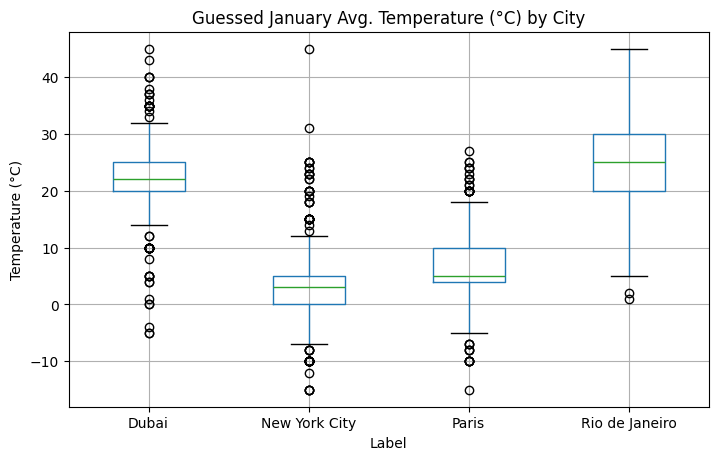

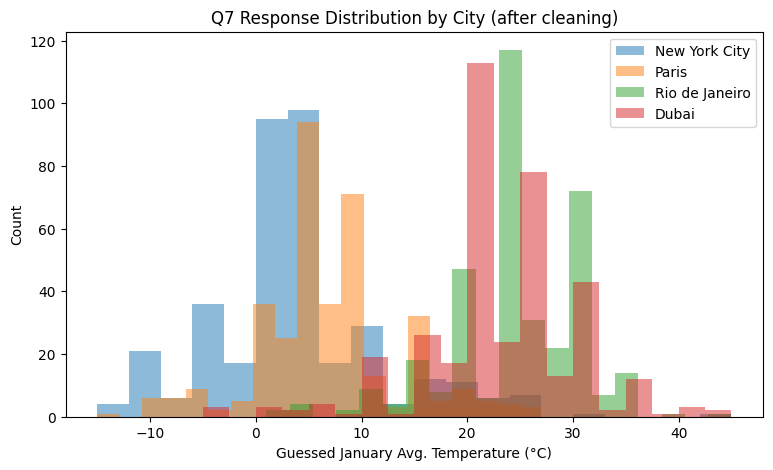

                count       mean       std   min   25%   50%   75%   max
Label                                                                   
Dubai           367.0  22.313351  7.194595  -5.0  20.0  22.0  25.0  45.0
New York City   365.0   3.256164  8.135578 -15.0   0.0   3.0   5.0  45.0
Paris           365.0   6.942466  6.722173 -15.0   4.0   5.0  10.0  27.0
Rio de Janeiro  365.0  24.542466  6.176567   1.0  20.0  25.0  30.0  45.0


In [8]:
# Boxplot: does temperature guess distribution differ meaningfully by city?
df_master.boxplot(column='Q7_clipped', by='Label', figsize=(8, 5))
plt.title('Guessed January Avg. Temperature (°C) by City')
plt.suptitle('')
plt.ylabel('Temperature (°C)')
plt.show()

# Histogram: distribution shape per city, overlaid
plt.figure(figsize=(9, 5))
for city in df_master['Label'].unique():
    subset = df_master.loc[df_master['Label'] == city, 'Q7_clipped']
    plt.hist(subset, bins=20, alpha=0.5, label=city)
plt.xlabel('Guessed January Avg. Temperature (°C)')
plt.ylabel('Count')
plt.title('Q7 Response Distribution by City (after cleaning)')
plt.legend()
plt.show()

# Summary stats table
print(df_master.groupby('Label')['Q7_clipped'].describe())

Dubai and Rio cluster around 22–25°C (median), New York and Paris cluster around 3–5°C. Based on this, we infer Q7 can differentiate "warm city" vs. "cold city" fairly cleanly, even if it's less clear at separating within those two pairs (Dubai vs. Rio, NYC vs. Paris).

Step 5: Standardization

In [9]:
# Standardize using training split statistics
X_raw = df_master[['Q7_clipped']].to_numpy()
mu = X_raw[train_idx].mean()
sigma = X_raw[train_idx].std()
X_std = (X_raw - mu) / sigma

def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

# Linear feature set: [bias, temperature]
X_linear = add_bias(X_std)

# Polynomial feature set: [bias, temperature, temperature^2]
X_quad = add_bias(np.hstack([X_std, X_std ** 2]))

print(f"Standardization stats (from training split only): mean={mu:.2f}°C, std={sigma:.2f}°C")

Standardization stats (from training split only): mean=14.26°C, std=11.89°C


Step 6: Data splitting for Q7

In [10]:
X_train_lin, X_val_lin = X_linear[train_idx], X_linear[val_idx]
X_train_quad, X_val_quad = X_quad[train_idx], X_quad[val_idx]

y_train_raw = df_master['Label'].iloc[train_idx].to_numpy()
y_val_raw = df_master['Label'].iloc[val_idx].to_numpy()

print("=== Q7 INDEPENDENT PARTITIONS READY ===")
print(f"X_train_lin shape: {X_train_lin.shape} | X_val_lin shape: {X_val_lin.shape}")

=== Q7 INDEPENDENT PARTITIONS READY ===
X_train_lin shape: (817, 2) | X_val_lin shape: (205, 2)


Step 7: Training

In [11]:
def exp_softmax(logits):
    """
    Computes the numerically stable softmax activation.
    logits: Shape (N, K) raw predictions
    """
    shift_logits = logits - np.max(logits, axis=1, keepdims=True)
    exps = np.exp(shift_logits)
    return exps / np.sum(exps, axis=1, keepdims=True)

def compute_cross_entropy_loss(X, y_one_hot, weights):
    """
    Computes categorical cross-entropy loss over a partitioned set.
    """
    N = X.shape[0]
    probs = exp_softmax(np.dot(X, weights))
    probs = np.clip(probs, 1e-15, 1.0 - 1e-15)
    return -np.sum(y_one_hot * np.log(probs)) / N

def convert_to_one_hot(y_labels, unique_cities=None):
    """
    Maps text city strings uniformly into structured 2D matrices.
    """
    if unique_cities is None:
        unique_cities = sorted(list(np.unique(y_labels)))
    mapping = {city: i for i, city in enumerate(unique_cities)}

    one_hot = np.zeros((len(y_labels), len(unique_cities)))
    for idx, label in enumerate(y_labels):
        one_hot[idx, mapping[label]] = 1.0
    return one_hot, unique_cities

def train_logistic_regression(X_train, y_train_oh, X_val, y_val_oh, alpha=0.5, epochs=500, mode='batch', decay_rate=None):
    N, D = X_train.shape
    K = y_train_oh.shape[1]
    weights = np.zeros((D, K))
    train_loss_history, val_loss_history = [], []
    lr_current = alpha

    for epoch in range(epochs):
        if mode == 'batch':
            probs = exp_softmax(np.dot(X_train, weights))
            gradient = np.dot(X_train.T, (probs - y_train_oh)) / N
            weights -= lr_current * gradient
        elif mode == 'sgd':
            for idx in np.random.permutation(N):
                xi, yi = X_train[idx:idx+1], y_train_oh[idx:idx+1]
                probs = exp_softmax(np.dot(xi, weights))
                gradient = np.dot(xi.T, (probs - yi))
                weights -= lr_current * gradient
            if decay_rate:
                lr_current *= decay_rate

        train_loss_history.append(compute_cross_entropy_loss(X_train, y_train_oh, weights))
        val_loss_history.append(compute_cross_entropy_loss(X_val, y_val_oh, weights))

    return weights, train_loss_history, val_loss_history

def compute_accuracy(X, y_raw_labels, weights, city_order):
    probs = exp_softmax(np.dot(X, weights))
    predicted_indices = np.argmax(probs, axis=1)
    predicted_labels = np.array([city_order[i] for i in predicted_indices])
    return np.mean(predicted_labels == y_raw_labels) * 100

Step 7.1: Hyperparameter tuning (linear vs. quadratic feature mapping)

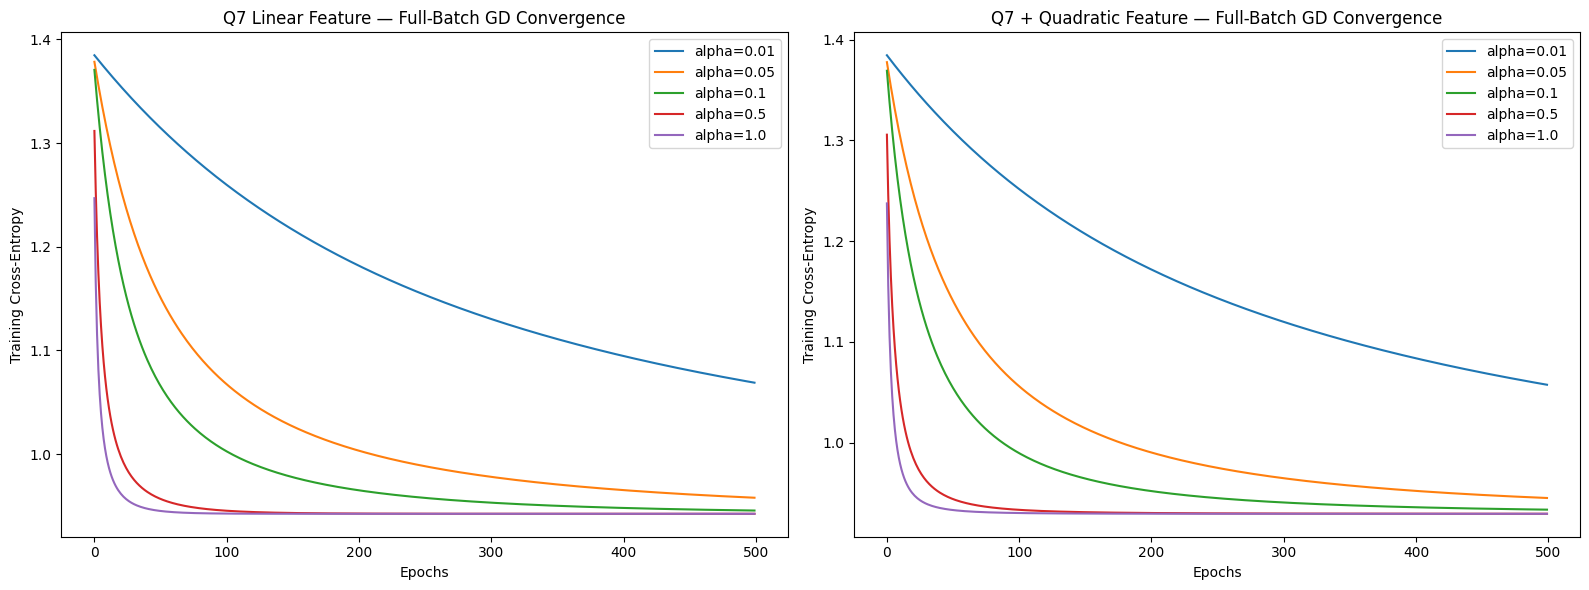

In [12]:
y_train_oh, city_order = convert_to_one_hot(y_train_raw)
y_val_oh, _ = convert_to_one_hot(y_val_raw, unique_cities=city_order)

epochs_to_run = 500
learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for lr in learning_rates:
    _, train_hist, _ = train_logistic_regression(
        X_train_lin, y_train_oh, X_val_lin, y_val_oh, alpha=lr, epochs=epochs_to_run, mode='batch')
    axes[0].plot(train_hist, label=f'alpha={lr}')
axes[0].set_title('Q7 Linear Feature — Full-Batch GD Convergence')
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Training Cross-Entropy'); axes[0].legend()

for lr in learning_rates:
    _, train_hist, _ = train_logistic_regression(
        X_train_quad, y_train_oh, X_val_quad, y_val_oh, alpha=lr, epochs=epochs_to_run, mode='batch')
    axes[1].plot(train_hist, label=f'alpha={lr}')
axes[1].set_title('Q7 + Quadratic Feature — Full-Batch GD Convergence')
axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Training Cross-Entropy'); axes[1].legend()

plt.tight_layout()
plt.show()

Both linear and quadratic converge to nearly the same loss (~0.94–0.95), and validation accuracy differs by about half a percentage point (56.6% linear vs. 57.1% quadratic at their best learning rates), which is well within noise for a 205-row validation set. Thus, we can conclude that the squared term doesn't meaningfully help, which makes sense given the boxplot. Q7 mostly separates "warm cities" from "cold cities" along a single direction, it isn't doing a U-shaped thing. It makes sense to go with a simpler linear feature for the final model (fewer parameters, same performance, easier to justify directly ties back to Lecture 4's overfitting discussion).

Step 7.2: Train the final model

In [13]:
final_weights, _, _ = train_logistic_regression(
    X_train_lin, y_train_oh, X_val_lin, y_val_oh,
    alpha=0.5, epochs=500, mode='batch'
)

Step 8: Report training/validation accuracy

In [14]:
train_acc = compute_accuracy(X_train_lin, y_sub_train.to_numpy(), final_weights, city_order)
val_acc = compute_accuracy(X_val_lin, y_sub_val.to_numpy(), final_weights, city_order)

print("==================================================")
print(" Q7 LOGISTIC REGRESSION ACCURACY REPORT ")
print("==================================================")
print(f"Optimized Hyperparameters: Alpha = 0.5 | Epochs = 500")
print(f"Optimization Routine: Full-Batch Gradient Descent")
print(f"Feature: Standardized single continuous feature (Q7)\n")
print(f"Training Accuracy:   {train_acc:.2f}%")
print(f"Validation Accuracy: {val_acc:.2f}%")
print("==================================================")

 Q7 LOGISTIC REGRESSION ACCURACY REPORT 
Optimized Hyperparameters: Alpha = 0.5 | Epochs = 500
Optimization Routine: Full-Batch Gradient Descent
Feature: Standardized single continuous feature (Q7)

Training Accuracy:   55.94%
Validation Accuracy: 56.59%


Train accuracy 55.94%, validation accuracy 56.59%, against a 25% random-guess baseline for 4 classes, more than double the baseline from a single feature. Training and validation accuracy are close together (no overfitting signal), which is expected given there's only one parameter (plus bias) per class, there's essentially no capacity to overfit here.

Q7 alone is good at telling "hot city" from "cold city" but weaker at Dubai-vs-Rio and NYC-vs-Paris, since their January temperature guesses overlap heavily. That's exactly why this is one sub-model as it needs the other questions' sub-models to resolve the ambiguity.